# Анализ перевозок грузов по видам транспорта в России (2000–2024)

## Описание
Ноутбук содержит анализ двух таблиц из файла PerevGruz.xlsx:
1. **Лист 1**: Перевозки грузов по видам транспорта (млн тонн).
2. **Лист 2**: Структура перевозок грузов по видам транспорта (процент).

Включает:
- загрузку данных с обоих листов;
- построение графиков по объёмам перевозок;
- анализ структуры (доли) перевозок;
- дополнительные виды визуализаций (heatmap, boxplot, scatter, area chart);
- сравнительный анализ тенденций.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# ====== ЛИСТ 1: Объёмы перевозок (млн тонн) ======
data1 = {
    'Год': [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'железнодорожный': [1046.8, 1057.5, 1083.7, 1160.9, 1221.2, 1273.3, 1311.6, 1344.6, 1304.4, 1108.8, 1312.0, 1381.7, 1421.1, 1381.2, 1375.4, 1329.0, 1325.2, 1384.3, 1410.9, 1398.6, 1358.5, 1403.9, 1351.3, 1365.2, 1306.1],
    'автомобильный': [5878.4, 6125.3, 6347.7, 6468.1, 6567.8, 6684.6, 6753.3, 6861.4, 6893.1, 5240.5, 5236.4, 5663.1, 5841.6, 5635.3, 5416.7, 5356.7, 5396.8, 5403.9, 5544.4, 5735.3, 5404.7, 5581.7, 6210.6, 6491.2, 6775.9],
    'газопроводный': [511.2, 508.8, 513.8, 544.5, 555.1, 565.8, 581.1, 571.6, 578.6, 480.0, 536.6, 555.1, 541.1, 537.5, 512.0, 493.0, 509.4, 548.8, 566.4, 550.9, 511.6, 574.6, 484.3, np.nan, np.nan],
    'нефтепроводный': [294.6, 319.7, 359.8, 404.3, 441.5, 454.1, 460.8, 461.8, 456.4, 474.4, 491.7, 543.8, 523.4, 524.6, 532.1, 543.3, 543.4, 553.4, 561.1, 567.7, 509.5, 523.9, 544.4, np.nan, np.nan],
    'нефтепродуктопроводный': [23.1, 24.9, 25.7, 27.6, 27.6, 28.2, 28.4, 28.7, 31.6, 30.6, 33.2, 32.0, 32.0, 33.1, 34.0, 34.7, 35.2, 36.1, 41.8, 40.5, 40.4, 42.9, 44.1, np.nan, np.nan],
    'морской': [35.4, 33.8, 37.3, 35.7, 29.1, 26.0, 25.4, 28.1, 35.2, 37.4, 37.0, 34.0, 18.3, 16.7, 15.8, 18.8, 24.6, 26.4, 23.2, 23.2, 24.7, 23.4, 27.6, 33.2, 31.9],
    'внутренний_водный': [116.8, 129.5, 118.7, 125.8, 135.0, 134.2, 139.2, 153.4, 150.8, 96.9, 102.4, 126.2, 140.5, 134.9, 119.1, 121.4, 118.0, 118.5, 116.2, 108.2, 109.0, 110.5, 116.4, 109.3, 105.4],
    'воздушный': [0.8, 0.9, 0.9, 0.8, 0.9, 0.8, 0.9, 1.0, 1.0, 0.9, 1.1, 1.2, 1.2, 1.2, 1.3, 1.0, 1.1, 1.3, 1.3, 1.3, 1.3, 1.6, 0.7, 0.6, 0.6]
}

df1 = pd.DataFrame(data1)

# ====== ЛИСТ 2: Структура перевозок (%) ======
data2 = {
    'Год': [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'железнодорожный': [13.2, 12.9, 12.8, 13.2, 13.6, 13.9, 14.1, 14.2, 13.8, 14.8, 16.9, 16.6, 16.7, 16.7, 17.2, 16.8, 16.7, 17.1, 17.1, 16.6, 17.1, 17.0, 15.5, 15.1, 14.1],
    'воздушный': [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.02, 0.01, 0.01, 0.02, 0.02, 0.02, 0.02, 0.02, 0.01, 0.01, 0.01],
    'автомобильный': [74.4, 74.7, 74.8, 73.9, 73.2, 73.0, 72.6, 72.7, 72.9, 70.2, 67.6, 67.9, 68.5, 68.2, 67.6, 67.8, 67.8, 67.0, 67.1, 68.0, 67.9, 67.6, 70.7, 71.6, 73.0],
    'водный_транспорт': [1.9, 2.0, 1.8, 1.8, 1.8, 1.7, 1.8, 1.9, 2.0, 1.8, 1.8, 1.9, 1.9, 1.8, 1.7, 1.8, 1.8, 1.8, 1.7, 1.6, 1.7, 1.6, 1.6, 1.6, 1.4],
    'трубопроводный': [10.5, 10.4, 10.6, 11.1, 11.4, 11.4, 11.5, 11.2, 11.3, 13.2, 13.7, 13.6, 12.9, 13.3, 13.5, 13.6, 13.7, 14.1, 14.1, 13.8, 13.3, 13.8, 12.2, 11.7, 11.5]
}

df2 = pd.DataFrame(data2)

print("Лист 1 (объёмы, млн тонн):")
print(df1.head())
print("Лист 2 (структура, %):")
df2.head()

Лист 1 (объёмы, млн тонн):
    Год  железнодорожный  автомобильный  газопроводный  нефтепроводный  \
0  2000           1046.8         5878.4          511.2           294.6   
1  2001           1057.5         6125.3          508.8           319.7   
2  2002           1083.7         6347.7          513.8           359.8   
3  2003           1160.9         6468.1          544.5           404.3   
4  2004           1221.2         6567.8          555.1           441.5   

   нефтепродуктопроводный  морской  внутренний_водный  воздушный  
0                    23.1     35.4              116.8        0.8  
1                    24.9     33.8              129.5        0.9  
2                    25.7     37.3              118.7        0.9  
3                    27.6     35.7              125.8        0.8  
4                    27.6     29.1              135.0        0.9  
Лист 2 (структура, %):


,Год,железнодорожный,воздушный,автомобильный,водный_транспорт,трубопроводный
0,2000,13.2,0.01,74.4,1.9,10.5
1,2001,12.9,0.01,74.7,2.0,10.4
2,2002,12.8,0.01,74.8,1.8,10.6
3,2003,13.2,0.01,73.9,1.8,11.1
4,2004,13.6,0.01,73.2,1.8,11.4


In [2]:
print("=== Обзор Листа 1 ===")
print(df1.describe())
print("=== Обзор Листа 2 ===")
df2.describe()


=== Обзор Листа 1 ===
               Год  железнодорожный  автомобильный  газопроводный  \
count    25.000000        25.000000      25.000000      23.000000   
mean   2012.000000      1296.688000    5980.580000     536.165217   
std       7.359801       115.452553     572.227786      30.909349   
min    2000.000000      1046.800000    5236.400000     480.000000   
25%    2006.000000      1273.300000    5416.700000     511.400000   
50%    2012.000000      1329.000000    5841.600000     541.100000   
75%    2018.000000      1381.200000    6491.200000     560.450000   
max    2024.000000      1421.100000    6893.100000     581.100000   

       нефтепроводный  нефтепродуктопроводный    морской  внутренний_водный  \
count       23.000000               23.000000  25.000000          25.000000   
mean       482.160870               32.886957  28.088000         122.252000   
std         76.575404                5.936812   6.748723          14.587584   
min        294.600000               23.1

,Год,железнодорожный,воздушный,автомобильный,водный_транспорт,трубопроводный
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.0000
mean,2012.000000,15.348000,0.012400,70.428000,1.768000,12.4560
std,7.359801,1.614806,0.004359,2.825409,0.137598,1.2738
min,2000.000000,12.800000,0.010000,67.000000,1.400000,10.4000
25%,2006.000000,13.900000,0.010000,67.800000,1.700000,11.4000
50%,2012.000000,15.500000,0.010000,70.200000,1.800000,12.9000
75%,2018.000000,16.800000,0.010000,73.000000,1.800000,13.6000
max,2024.000000,17.200000,0.020000,74.800000,2.000000,14.1000


## График 1. Динамика всех видов транспорта (абсолютные объёмы)

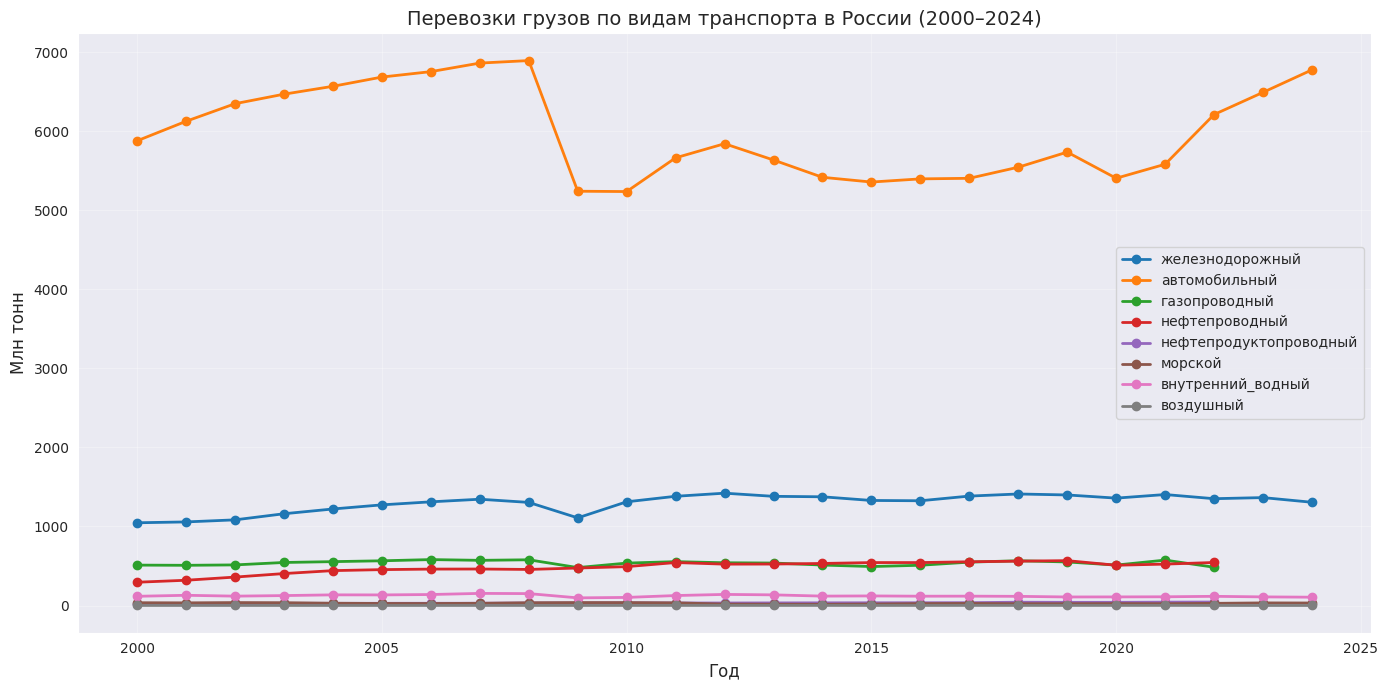

In [3]:
# График 1. Динамика всех видов транспорта (абсолютные объёмы)
plt.figure(figsize=(14, 7))
for col in df1.columns:
    if col != 'Год':
        plt.plot(df1['Год'], df1[col], marker='o', label=col, linewidth=2)

plt.title('Перевозки грузов по видам транспорта в России (2000–2024)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Млн тонн', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по График 1:
- **Автомобильный транспорт** — абсолютный лидер.
- **Железнодорожный транспорт** стабилен и второй по объёмам.
- Трубопроводные виды демонстрируют плавные изменения, без резких скачков.


## График 2. Структура перевозок в процентах

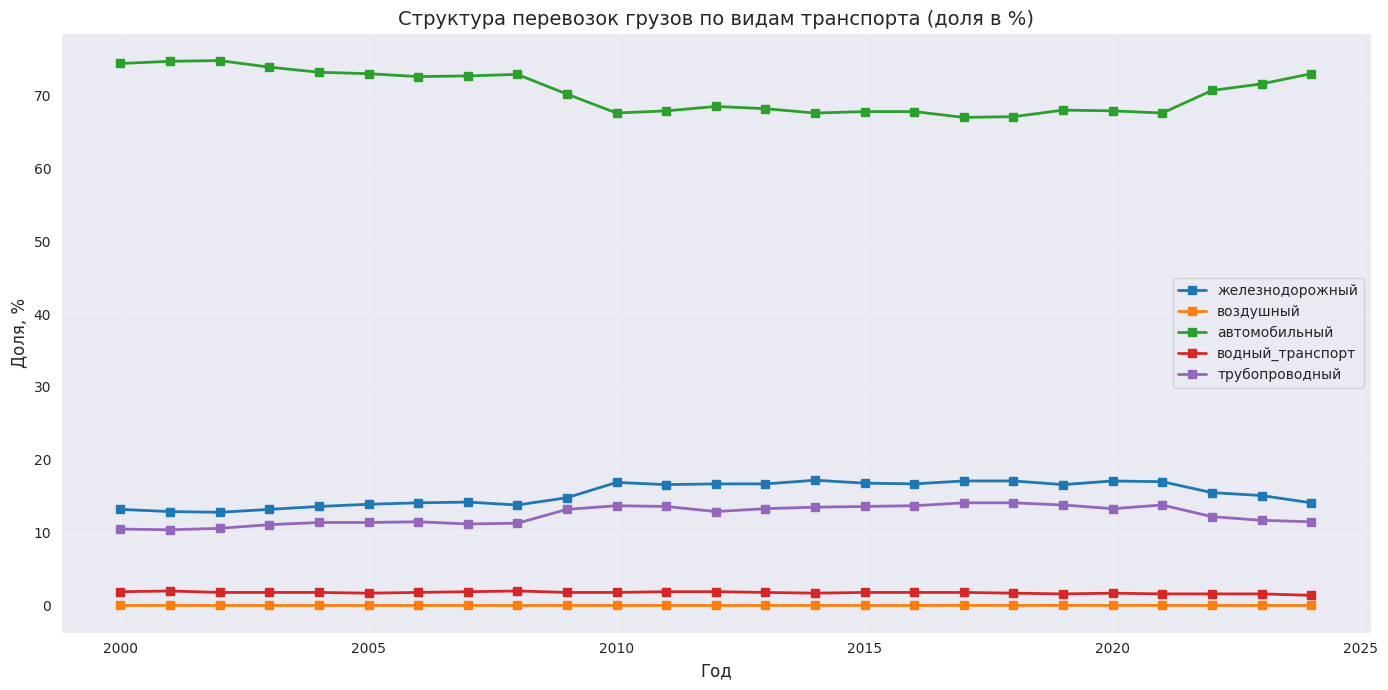

In [4]:
# График 2. Структура перевозок в процентах
plt.figure(figsize=(14, 7))
for col in df2.columns:
    if col != 'Год':
        plt.plot(df2['Год'], df2[col], marker='s', label=col, linewidth=2)

plt.title('Структура перевозок грузов по видам транспорта (доля в %)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля, %', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по График 2:
- Доля автомобильного транспорта держится в коридоре 67–75%.
- Железнодорожный транспорт усилил свои позиции до ~17%, затем немного снизился.
- Трубопроводный транспорт стабильно занимает 11–14%.
- Водный и воздушный — небольшие, но устойчивые по доле.


## Дополнительные виды визуализаций

In [5]:
# Подготовка вспомогательных датафреймов

pipe_cols = ['газопроводный', 'нефтепроводный', 'нефтепродуктопроводный']
df1['трубопроводный_итого'] = df1[pipe_cols].sum(axis=1)

# Объединённый df по авто и ж/д
merge_cols = ['Год', 'автомобильный', 'железнодорожный']
df_merge = df1[merge_cols].merge(df2[['Год', 'автомобильный', 'железнодорожный']], on='Год', suffixes=('_объем', '_доля'))


## График 3. Тепловая карта корреляций

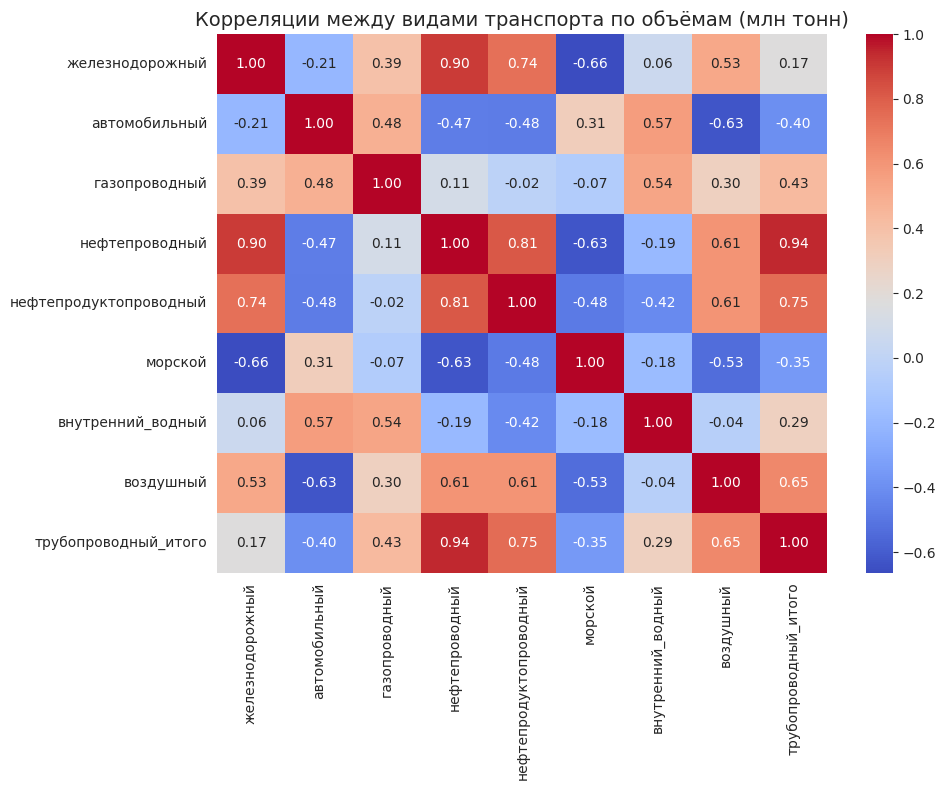

In [6]:
# График 3. Тепловая карта корреляций по объёмам
plt.figure(figsize=(10, 8))
num_cols = [c for c in df1.columns if c != 'Год']
cor_matrix = df1[num_cols].corr()

sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляции между видами транспорта по объёмам (млн тонн)', fontsize=14)
plt.tight_layout()
plt.show()


### Выводы по График 3 (heatmap):
- Автомобильный и железнодорожный транспорт сильно коррелируют — циклы спроса общие.
- Газо-, нефте- и нефтепродуктопроводный имеют высокую взаимную корреляцию.
- Морской, внутренний водный и воздушный слабее связаны с основной группой.


## График 4. Диаграмма размаха приростов автоперевозок

/tmp/ipykernel_13211/2209503844.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(auto['прирост_%'].dropna(), vert=True, labels=['авто прирост %'])


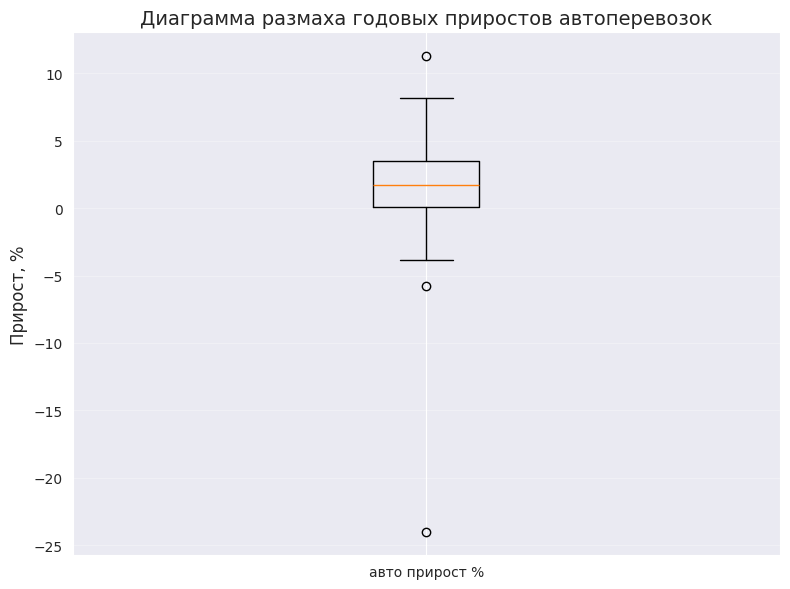

In [7]:
# График 4. Диаграмма размаха для приростов автоперевозок

auto = df1[['Год', 'автомобильный']].copy()
auto['прирост_%'] = auto['автомобильный'].pct_change() * 100

plt.figure(figsize=(8, 6))
plt.boxplot(auto['прирост_%'].dropna(), vert=True, labels=['авто прирост %'])
plt.title('Диаграмма размаха годовых приростов автоперевозок', fontsize=14)
plt.ylabel('Прирост, %', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по График 4 (boxplot):
- Основная масса приростов — около нуля, что говорит о зрелом рынке.
- Отрицательные выбросы — кризисы и шоки спроса (2009, 2020).
- Положительные выбросы — периоды восстановления и перегрева.


## График 5. Скаттер-плот: объём vs доля

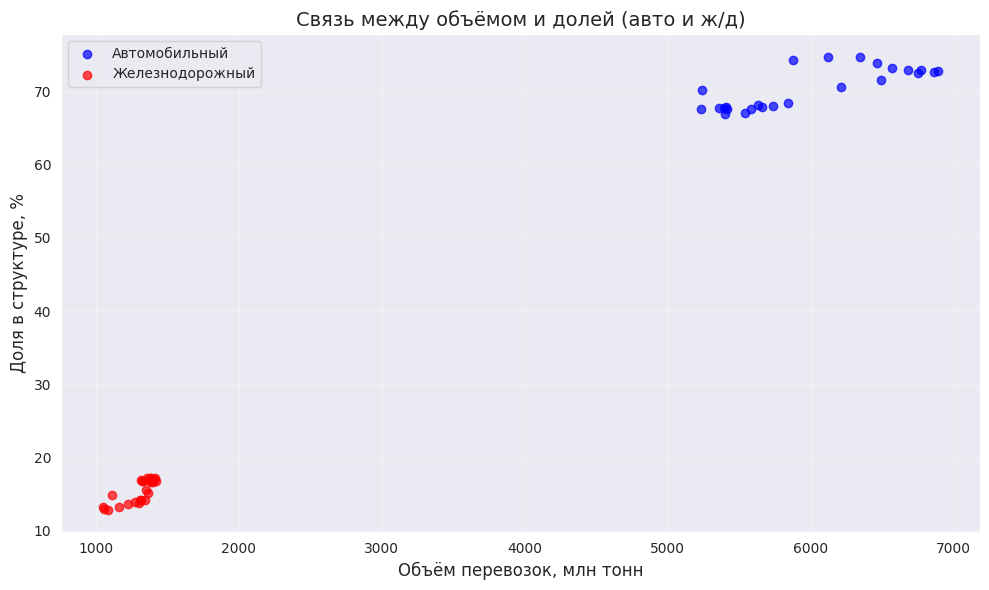

In [8]:
# График 5. Скаттер-плот: объём vs доля (авто и ж/д)

plt.figure(figsize=(10, 6))
plt.scatter(df_merge['автомобильный_объем'], df_merge['автомобильный_доля'], color='blue', alpha=0.7, label='Автомобильный')
plt.scatter(df_merge['железнодорожный_объем'], df_merge['железнодорожный_доля'], color='red', alpha=0.7, label='Железнодорожный')

plt.xlabel('Объём перевозок, млн тонн', fontsize=12)
plt.ylabel('Доля в структуре, %', fontsize=12)
plt.title('Связь между объёмом и долей (авто и ж/д)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по График 5 (scatter):
- У автомобильного транспорта почти линейная связь объём–доля.
- У железнодорожного — более рассеянная, структура может меняться без сильных скачков объёмов.


## График 6. Площадная диаграмма трубопроводного транспорта

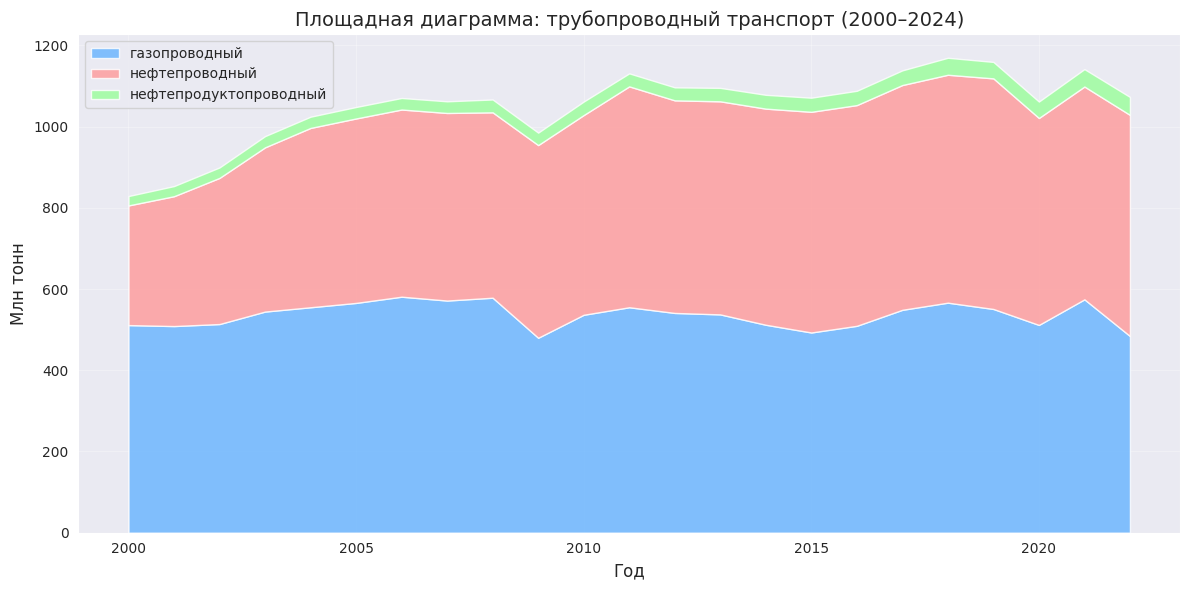

In [9]:
# График 6. Площадная диаграмма трубопроводного транспорта

plt.figure(figsize=(12, 6))
plt.stackplot(df1['Год'], df1['газопроводный'], df1['нефтепроводный'], df1['нефтепродуктопроводный'],
              labels=['газопроводный', 'нефтепроводный', 'нефтепродуктопроводный'],
              colors=['#66b3ff', '#ff9999', '#99ff99'], alpha=0.8)

plt.title('Площадная диаграмма: трубопроводный транспорт (2000–2024)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Млн тонн', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по График 6 (area chart):
- Газопроводный транспорт задаёт основную динамику всей группы.
- Нефтепроводный постепенно увеличивает вклад, затем стабилизируется.
- Нефтепродуктопроводный мал по объёму, но даёт плавный рост общей площади.
